# Classification Model: Predicting Red List Categories for Kenya's Data Deficient Species

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Build Feature Matrix

In [63]:
base_taxa = pd.read_csv(r"../data/processed/base_taxa.csv")
countries = pd.read_csv(r"../data/processed/countries.csv")
habitats = pd.read_csv(r"../data/processed/habitats.csv")
threats = pd.read_csv(r"../data/processed/threats.csv")
uses = pd.read_csv(r"../data/processed/uses.csv")
conservation_needed = pd.read_csv(r"../data/processed/conservation_needed.csv")
research_needed = pd.read_csv(r"../data/processed/research_needed.csv")

print(f"Total species: {len(base_taxa):,}")

Total species: 39,024


In [68]:
# Create simplified target variable
def simplify_category(cat):
    threatened = ['Vulnerable', 'Endangered', 'Critically Endangered']
    non_threatened = ['Least Concern', 'Near Threatened', 'Not Applicable','Lower Risk/near threatened', 'Lower Risk/least concern','Lower Risk/conservation dependent']
    extinct = ['Extinct', 'Extinct in the Wild', 'Regionally Extinct']
    
    if cat in threatened:
        return 'Threatened'
    elif cat in non_threatened:
        return 'Non-Threatened'
    elif cat in extinct:
        return 'Extinct'
    else:
        return 'Data Deficient'

base_taxa['simplified_category'] = base_taxa['redlistCategory'].apply(simplify_category)

# Build count features from relational tables
count_tables = {
    'n_countries': countries,
    'n_habitats': habitats,
    'n_threats': threats,
    'n_uses': uses,
    'n_conservation': conservation_needed,
    'n_research': research_needed,
}

feature_df = base_taxa[['internalTaxonId', 'className', 'populationTrend', 'simplified_category']].copy()

for col_name, table in count_tables.items():
    counts = table.groupby('internalTaxonId').size().reset_index(name=col_name)
    feature_df = feature_df.merge(counts, on='internalTaxonId', how='left')
    feature_df[col_name] = feature_df[col_name].fillna(0).astype(int)

print(f"Feature matrix shape: {feature_df.shape}")
feature_df.head()

Feature matrix shape: (39024, 10)


,internalTaxonId,className,populationTrend,simplified_category,n_countries,n_habitats,n_threats,n_uses,n_conservation,n_research
0,10030,CHONDRICHTHYES,Decreasing,Non-Threatened,76,3,3,6,0,4
1,11200,CHONDRICHTHYES,Decreasing,Threatened,47,4,4,0,4,6
2,232775771,REPTILIA,Decreasing,Threatened,9,5,24,3,5,6
3,12696,REPTILIA,Decreasing,Threatened,3,4,7,2,11,10
4,12776,AMPHIBIA,Decreasing,Threatened,1,5,9,2,4,3


In [69]:
feature_df.drop(feature_df[feature_df['simplified_category'] == 'Extinct'].index, inplace=True)
print(f"Feature matrix shape: {feature_df.shape}")

Feature matrix shape: (38824, 10)


In [70]:
feature_df.head()

,internalTaxonId,className,populationTrend,simplified_category,n_countries,n_habitats,n_threats,n_uses,n_conservation,n_research
0,10030,CHONDRICHTHYES,Decreasing,Non-Threatened,76,3,3,6,0,4
1,11200,CHONDRICHTHYES,Decreasing,Threatened,47,4,4,0,4,6
2,232775771,REPTILIA,Decreasing,Threatened,9,5,24,3,5,6
3,12696,REPTILIA,Decreasing,Threatened,3,4,7,2,11,10
4,12776,AMPHIBIA,Decreasing,Threatened,1,5,9,2,4,3


## 2. Identify Kenya's Data Deficient Species

In [ ]:
# Filter for Kenya species
kenya_ids = set(countries[countries['countryName'] == 'Kenya']['internalTaxonId'])

# Kenya DD species = species in Kenya AND classified as Data Deficient
kenya_dd = feature_df[
    (feature_df['internalTaxonId'].isin(kenya_ids)) &
    (feature_df['simplified_category'] == 'Data Deficient')
].copy()

print(f"Kenya DD species to predict: {len(kenya_dd)}")
print(f"\nTaxonomic class breakdown:")
print(kenya_dd['className'].value_counts())

Kenya DD species to predict: 335

Taxonomic class breakdown:
className
ACTINOPTERYGII    119
MAMMALIA           34
INSECTA            32
REPTILIA           22
HOLOTHUROIDEA      19
GASTROPODA         18
CEPHALOPODA        15
MAGNOLIOPSIDA      15
LILIOPSIDA         13
BIVALVIA           12
Name: count, dtype: int64


## 3. Prepare Train/Test Sets with One-Hot Encoding

In [71]:
train_pool = feature_df[feature_df['simplified_category'] != 'Data Deficient'].copy()

print(f"Training pool (non-DD, global): {len(train_pool):,}")
print(f"Prediction set (Kenya DD):      {len(kenya_dd)}")

cat_features = ['className', 'populationTrend']
num_features = ['n_countries', 'n_habitats', 'n_threats', 'n_uses', 'n_conservation', 'n_research']

# Target
y_all = train_pool['simplified_category']

train_idx, test_idx = train_test_split(
    train_pool.index, test_size=0.2, random_state=42, stratify=y_all
)

train_data = train_pool.loc[train_idx]
test_data = train_pool.loc[test_idx]

print(f"\nTrain: {len(train_data):,}, Test: {len(test_data):,}")

Training pool (non-DD, global): 35,204
Prediction set (Kenya DD):      335

Train: 28,163, Test: 7,041


In [72]:
# One-Hot Encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on training data only
ohe.fit(train_data[cat_features])

# Transform all three sets
train_cat_encoded = pd.DataFrame(
    ohe.transform(train_data[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=train_data.index
)
test_cat_encoded = pd.DataFrame(
    ohe.transform(test_data[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=test_data.index
)
kenya_dd_cat_encoded = pd.DataFrame(
    ohe.transform(kenya_dd[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=kenya_dd.index
)

# Combine encoded categoricals with numeric features
X_train = pd.concat([train_data[num_features].reset_index(drop=True),
                      train_cat_encoded.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_data[num_features].reset_index(drop=True),
                     test_cat_encoded.reset_index(drop=True)], axis=1)
X_kenya_dd = pd.concat([kenya_dd[num_features].reset_index(drop=True),
                         kenya_dd_cat_encoded.reset_index(drop=True)], axis=1)

y_train = train_data['simplified_category'].values
y_test = test_data['simplified_category'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"X_kenya_dd shape: {X_kenya_dd.shape}")
print(f"\nTotal features: {X_train.shape[1]} ({len(num_features)} numeric + {X_train.shape[1] - len(num_features)} one-hot encoded)")

X_train shape: (28163, 52)
X_test shape:  (7041, 52)
X_kenya_dd shape: (335, 52)

Total features: 52 (6 numeric + 46 one-hot encoded)


## 4. Handle Class Imbalance with SMOTE

Class distribution BEFORE SMOTE:
Non-Threatened    18217
Threatened         9946
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Non-Threatened    18217
Threatened        18217
Name: count, dtype: int64


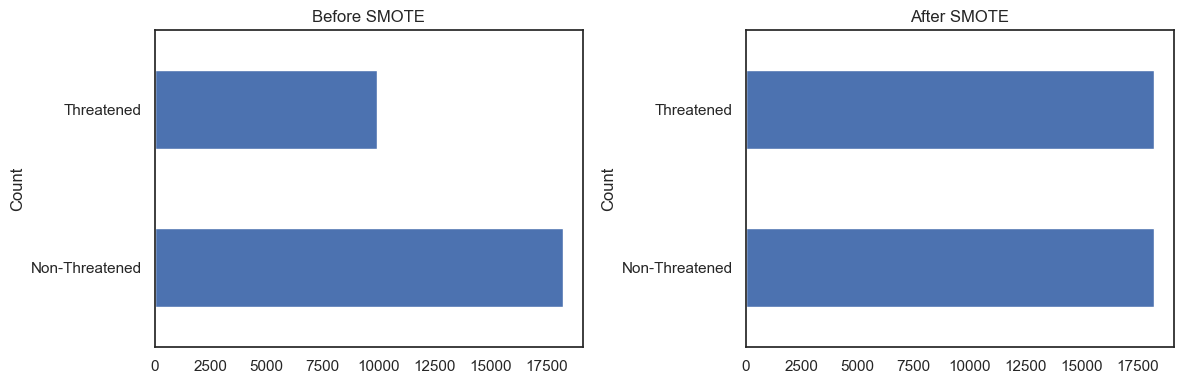

In [15]:
# Class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
before = pd.Series(y_train).value_counts()
print(before)
print()

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
after = pd.Series(y_train_smote).value_counts()
print(after)

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before.plot(kind='barh', ax=axes[0])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x')

after.plot(kind='barh', ax=axes[1])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

## 5. Logistic Regression

In [16]:
# Train Logistic Regression on SMOTE-balanced data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

# Evaluate on the original (unbalanced) test set
y_pred_lr = lr.predict(X_test)

print("Logistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Classification Report:
                precision    recall  f1-score   support

Non-Threatened       0.92      0.81      0.86      4554
    Threatened       0.72      0.87      0.79      2487

      accuracy                           0.83      7041
     macro avg       0.82      0.84      0.83      7041
  weighted avg       0.85      0.83      0.84      7041



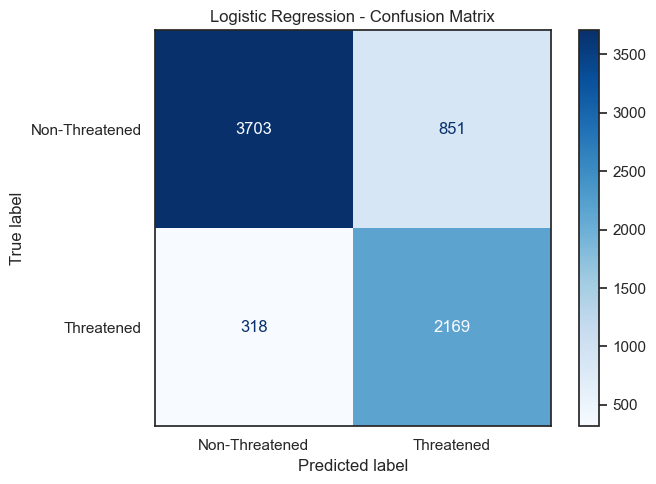

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [18]:
# Cross-validation on SMOTE-balanced data
lr_cv_scores = cross_val_score(lr, X_train_smote, y_train_smote, cv=5, scoring='f1_weighted')
print(f"Logistic Regression - 5-Fold CV F1 (weighted): {lr_cv_scores}")
print(f"Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

Logistic Regression - 5-Fold CV F1 (weighted): [0.84225291 0.84165314 0.83045376 0.84698978 0.83950056]
Mean: 0.8402 (+/- 0.0054)


## 6. Random Forest

In [ ]:
# on SMOTE-balanced data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

# eval on the original test set
y_pred_rf = rf.predict(X_test)

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest - Classification Report:
                precision    recall  f1-score   support

Non-Threatened       0.93      0.88      0.90      4554
    Threatened       0.79      0.87      0.83      2487

      accuracy                           0.87      7041
     macro avg       0.86      0.87      0.87      7041
  weighted avg       0.88      0.87      0.88      7041



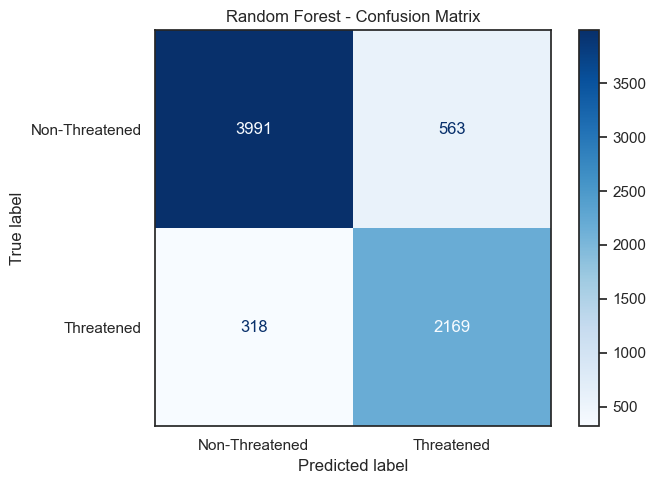

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Blues')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

In [23]:
# Cross-validation
rf_cv_scores = cross_val_score(rf, X_train_smote, y_train_smote, cv=5, scoring='f1_weighted')
print(f"Random Forest - 5-Fold CV F1 (weighted): {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest - 5-Fold CV F1 (weighted): [0.88636732 0.88280281 0.89087959 0.92364698 0.92072637]
Mean: 0.9009 (+/- 0.0176)


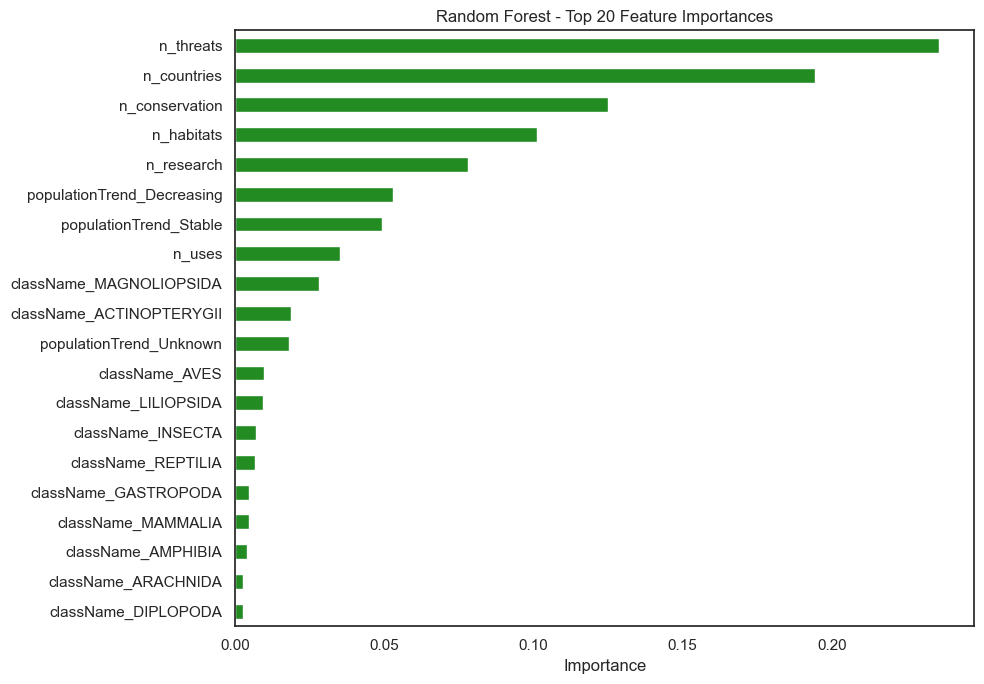

In [24]:
# Feature importance (top 20)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_20.sort_values().plot(kind='barh', color='forestgreen', ax=ax)
ax.set_title('Random Forest - Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Model Comparison

In [ ]:
# Side-by-side comparison
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (weighted)', 'CV F1 Mean', 'CV F1 Std'],
    'Logistic Regression': [accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average='weighted'),
        lr_cv_scores.mean(),
        lr_cv_scores.std()
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average='weighted'),
        rf_cv_scores.mean(),
        rf_cv_scores.std()
    ]
})

comparison[['Logistic Regression', 'Random Forest']] = comparison[['Logistic Regression', 'Random Forest']].round(4)
comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8340,0.8749
1,F1 (weighted),0.8368,0.8761
2,CV F1 Mean,0.8402,0.9009
3,CV F1 Std,0.0054,0.0176


## 8. Predict Red List Categories for Kenya's DD Species

In [26]:
# Predict using both models
kenya_dd_pred_lr = lr.predict(X_kenya_dd)
kenya_dd_pred_rf = rf.predict(X_kenya_dd)

# Build results dataframe
kenya_dd_results = kenya_dd[['internalTaxonId', 'className']].reset_index(drop=True)
kenya_dd_results['scientificName'] = base_taxa.set_index('internalTaxonId').loc[kenya_dd['internalTaxonId'].values, 'scientificName'].values
kenya_dd_results['pred_logistic_regression'] = kenya_dd_pred_lr
kenya_dd_results['pred_random_forest'] = kenya_dd_pred_rf

kenya_dd_results.head()

,internalTaxonId,className,scientificName,pred_logistic_regression,pred_random_forest
0,137075,INSECTA,Coptorhina nitefacta,Non-Threatened,Non-Threatened
1,137094,INSECTA,Onitis parvulus,Non-Threatened,Non-Threatened
2,137449,INSECTA,Copris morphaeus,Non-Threatened,Non-Threatened
3,137608,INSECTA,Onitis meyeri,Non-Threatened,Non-Threatened
4,137895,INSECTA,Onthophagus rugulipennis,Non-Threatened,Non-Threatened


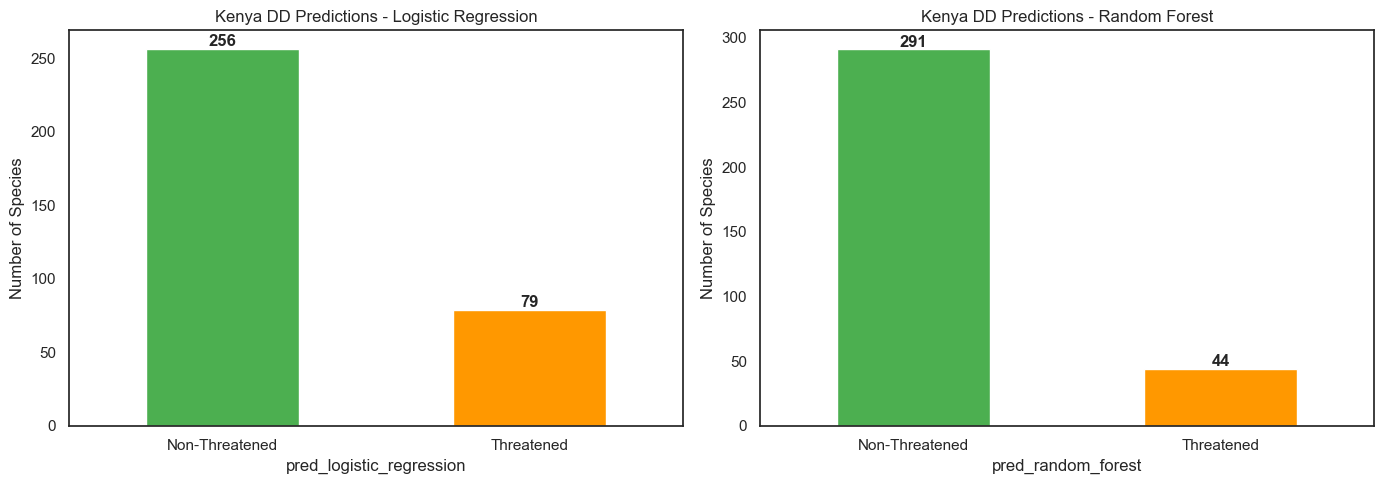

In [61]:
# Visualize prediction distributions from both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Non-Threatened': '#4CAF50', 'Threatened': '#FF9800'}

for ax, col, title in zip(axes,
    ['pred_logistic_regression', 'pred_random_forest'],
    ['Logistic Regression', 'Random Forest']):
    
    counts = kenya_dd_results[col].value_counts()
    bar_colors = [colors.get(cat, 'grey') for cat in counts.index]
    counts.plot(kind='bar', color=bar_colors, ax=ax)
    ax.set_title(f'Kenya DD Predictions - {title}')
    ax.set_ylabel('Number of Species')
    ax.tick_params(axis='x', rotation=0)
    
    # Add count labels
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

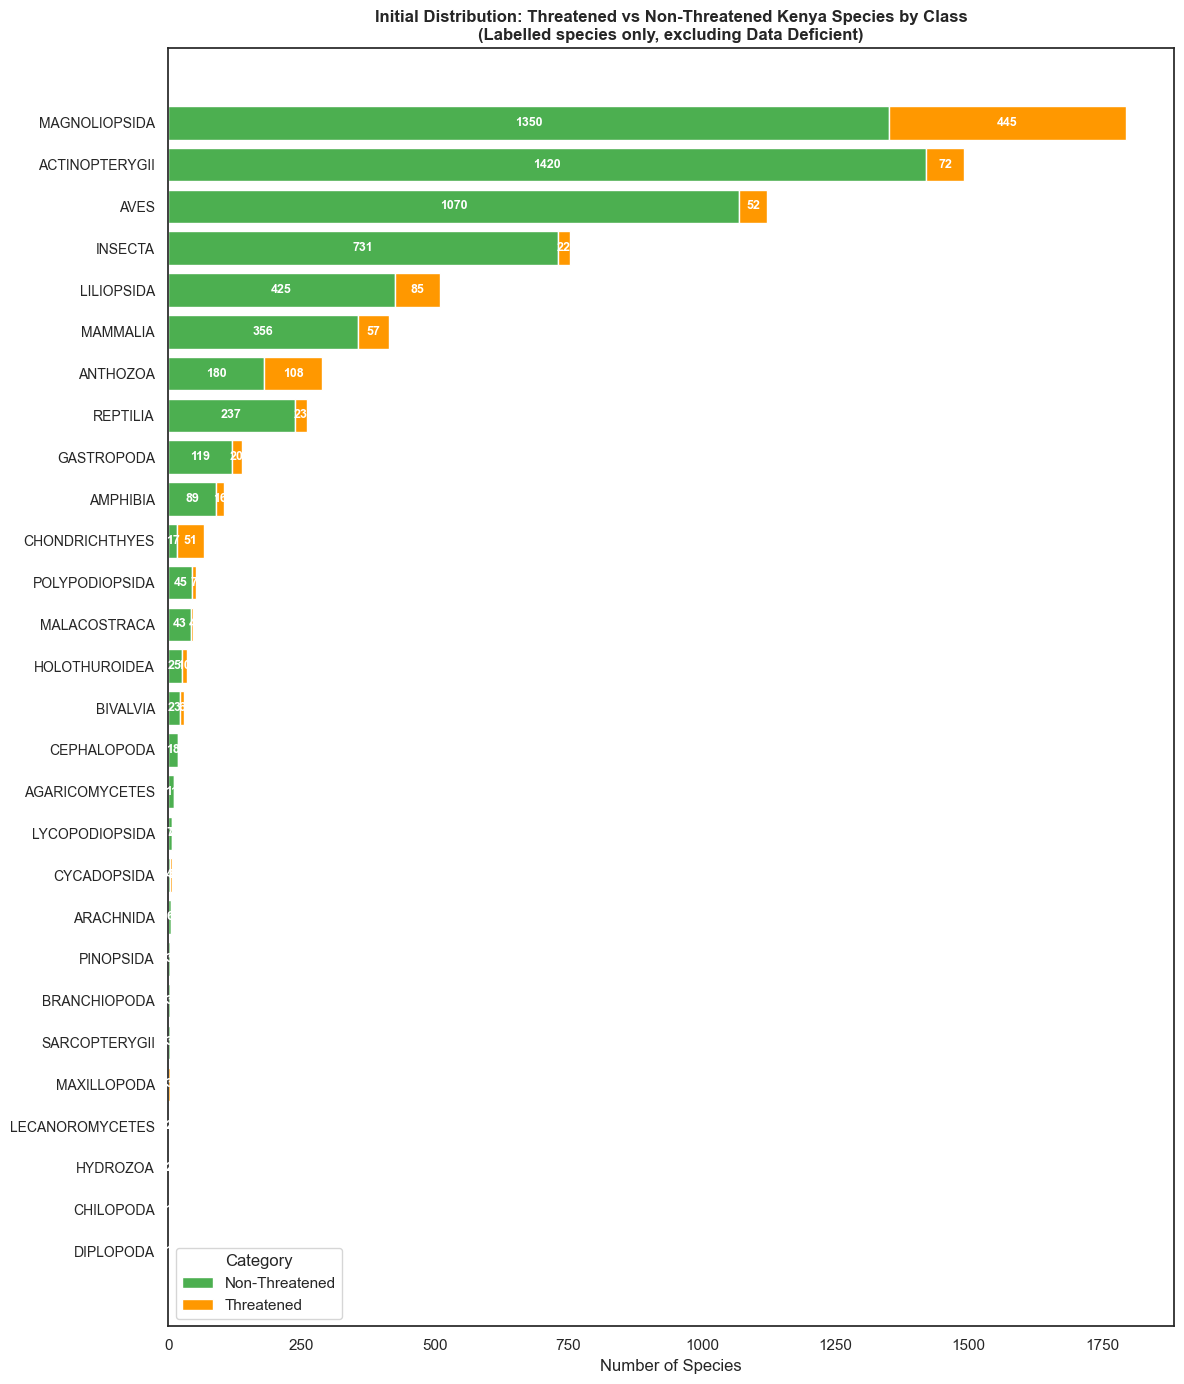

                 Non-Threatened  Threatened  Total
className                                         
MAGNOLIOPSIDA              1350         445   1795
ACTINOPTERYGII             1420          72   1492
AVES                       1070          52   1122
INSECTA                     731          22    753
LILIOPSIDA                  425          85    510
MAMMALIA                    356          57    413
ANTHOZOA                    180         108    288
REPTILIA                    237          23    260
GASTROPODA                  119          20    139
AMPHIBIA                     89          16    105
CHONDRICHTHYES               17          51     68
POLYPODIOPSIDA               45           7     52
MALACOSTRACA                 43           4     47
HOLOTHUROIDEA                25          10     35
BIVALVIA                     23           6     29
CEPHALOPODA                  18           0     18
AGARICOMYCETES               11           0     11
LYCOPODIOPSIDA                7

In [73]:
# Initial distribution of Threatened vs Non-Threatened for labelled Kenya species (all classes)
kenya_labelled = feature_df[
    (feature_df['internalTaxonId'].isin(kenya_ids)) &
    (feature_df['simplified_category'] != 'Data Deficient')
].copy()

ct = pd.crosstab(kenya_labelled['className'], kenya_labelled['simplified_category'])
ct.columns.name = None

# Sort classes by total species count
ct = ct.reindex(ct.sum(axis=1).sort_values().index)

fig, ax = plt.subplots(figsize=(12, max(6, len(ct) * 0.5)))

nt = ct.get('Non-Threatened', pd.Series(0, index=ct.index))
t  = ct.get('Threatened', pd.Series(0, index=ct.index))
y  = np.arange(len(ct))

ax.barh(y, nt, color='#4CAF50', label='Non-Threatened')
ax.barh(y, t, left=nt, color='#FF9800', label='Threatened')

for i, (nt_val, t_val) in enumerate(zip(nt, t)):
    if nt_val > 0:
        ax.text(nt_val / 2, i, str(nt_val), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if t_val > 0:
        ax.text(nt_val + t_val / 2, i, str(t_val), ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(ct.index, fontsize=10)
ax.set_xlabel('Number of Species')
ax.set_title('Initial Distribution: Threatened vs Non-Threatened Kenya Species by Class\n(Labelled species only, excluding Data Deficient)', fontweight='bold')
ax.legend(title='Category')
plt.tight_layout()
plt.show()

print(ct.assign(Total=ct.sum(axis=1)).sort_values('Total', ascending=False))

In [56]:
# Build complete class list from labelled + DD predictions (no duplicates)
all_classes = sorted(set(before.index) | set(dd_by_class.index))

# Reindex before/after to include all classes, filling missing with 0
before_full = before.reindex(all_classes).fillna(0).astype(int)
# Ensure both columns exist
for col in ['Non-Threatened', 'Threatened']:
    if col not in before_full.columns:
        before_full[col] = 0
after_full = before_full.add(
    dd_by_class.reindex(all_classes).fillna(0).astype(int), fill_value=0
).astype(int)

n_cols = 6
n_rows = (len(all_classes) + n_cols - 1) // n_cols

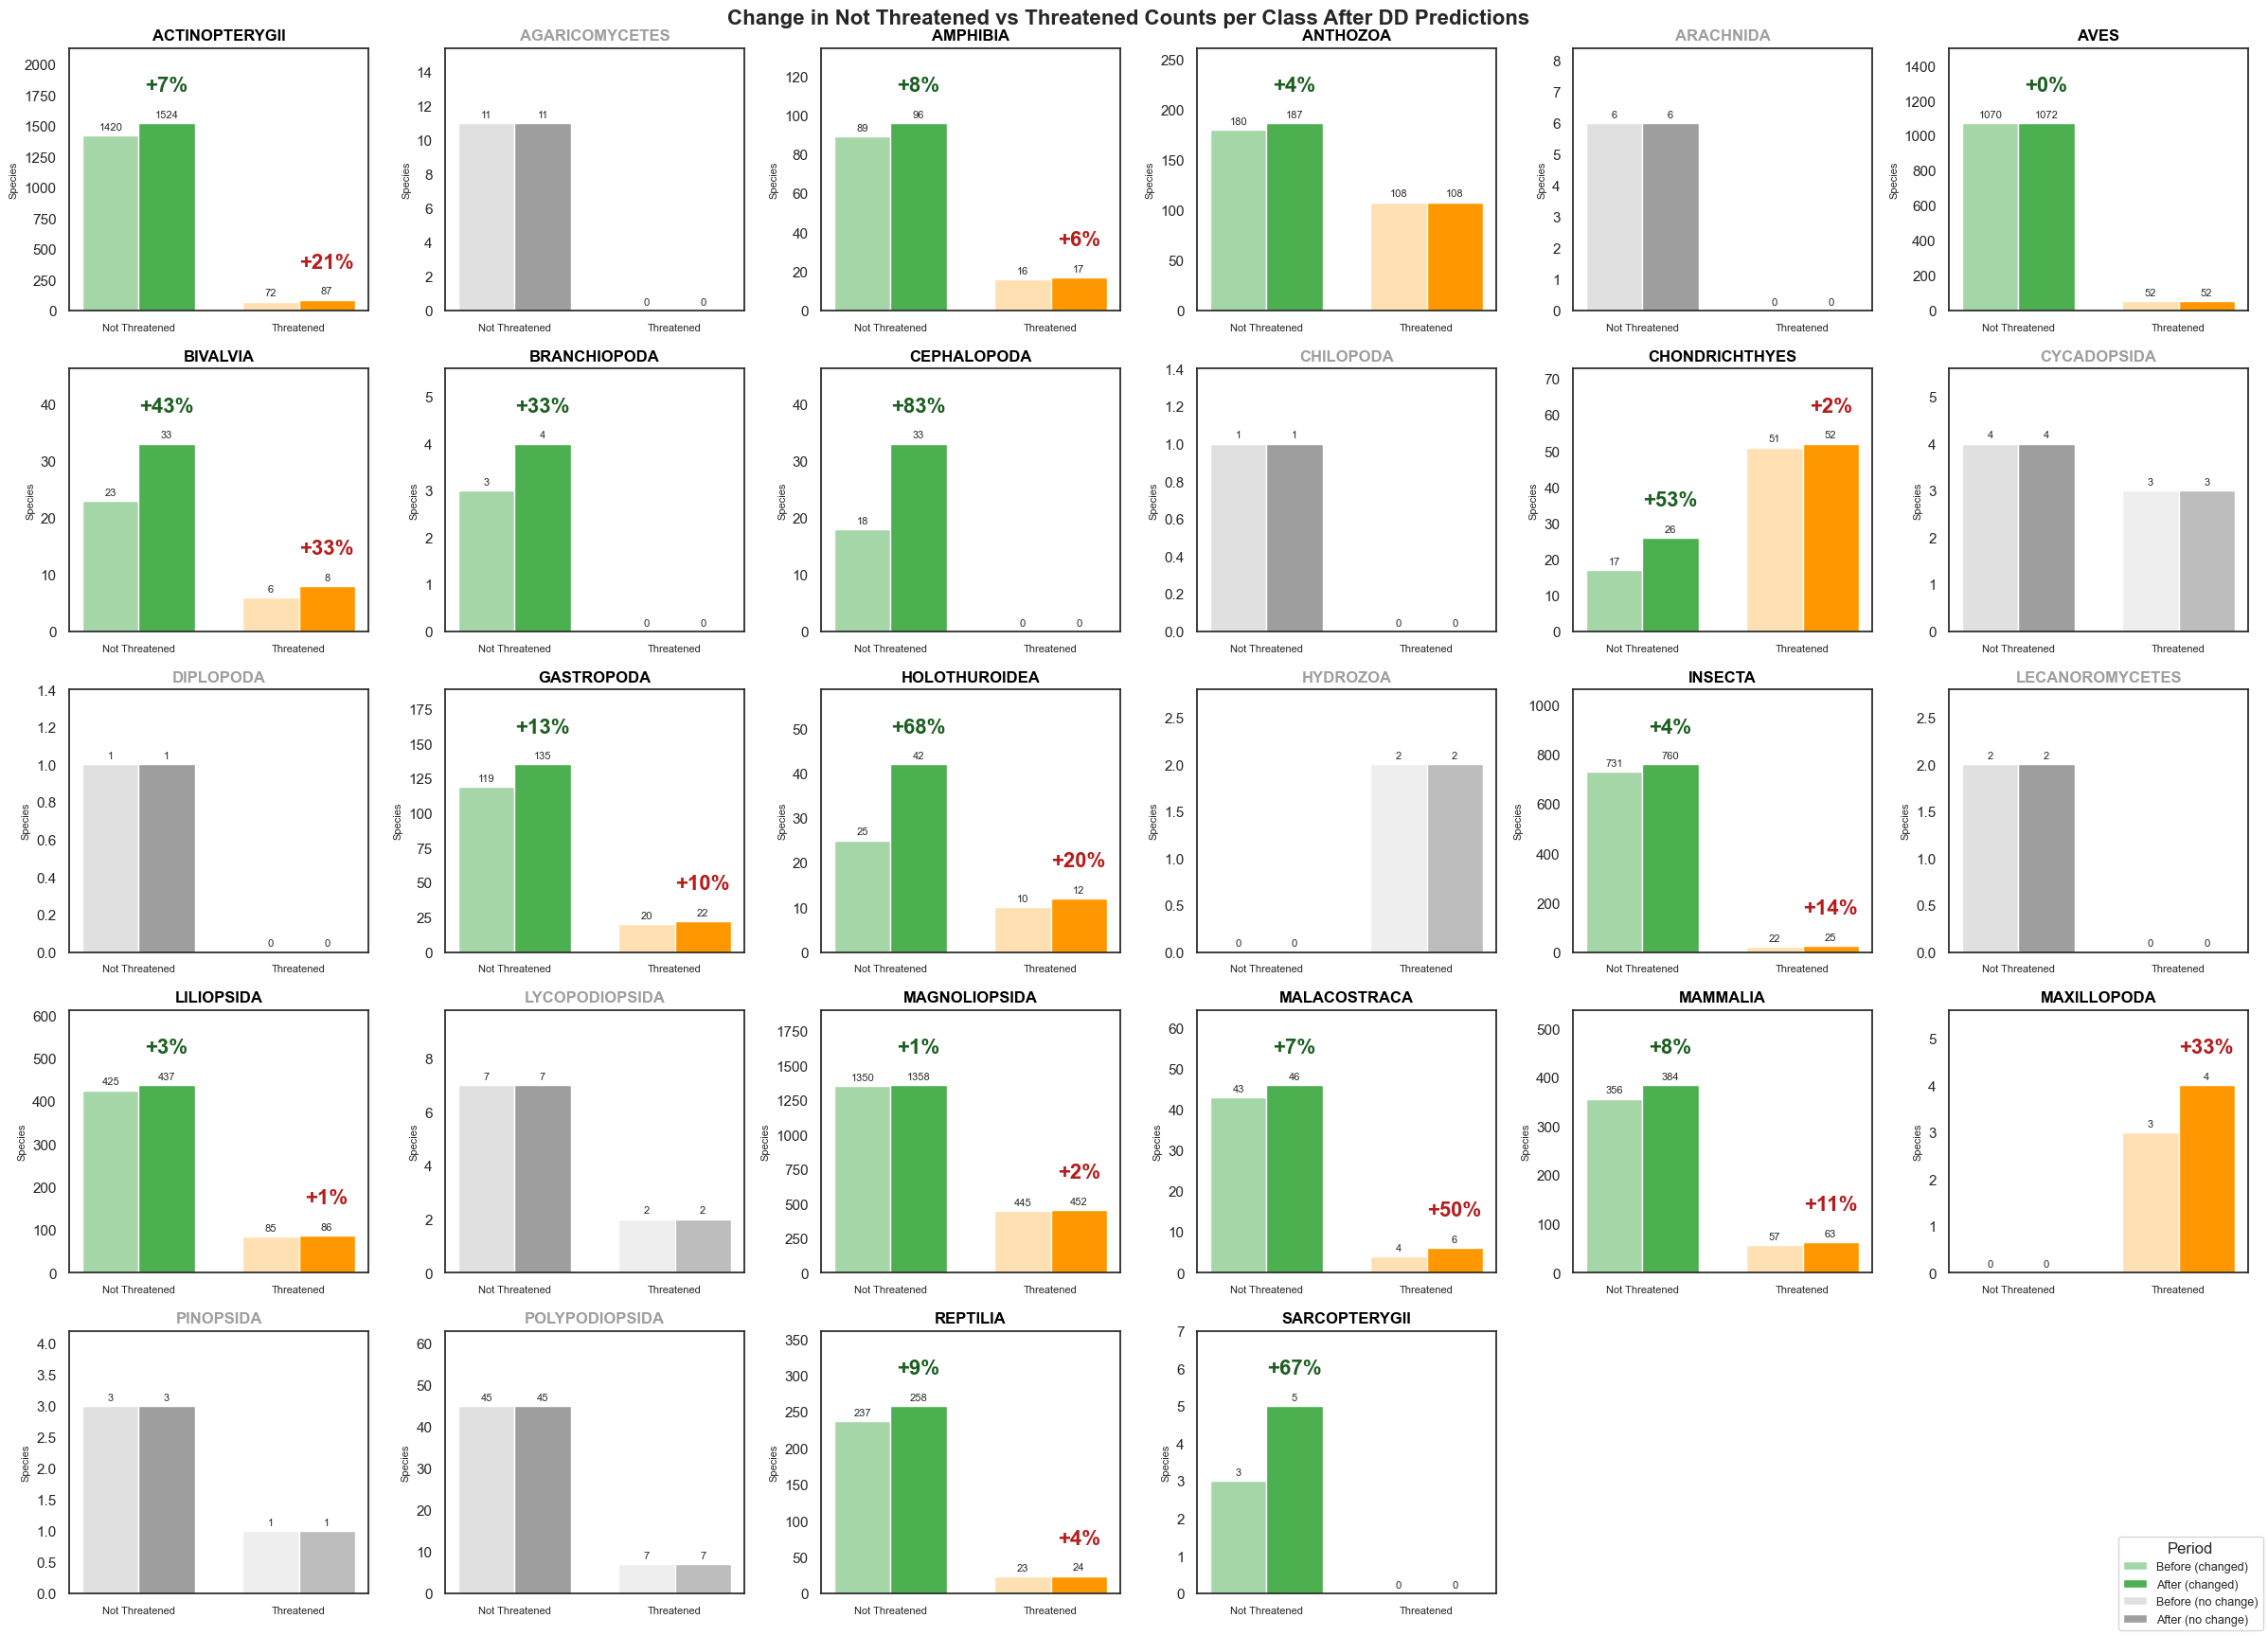

In [58]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 3.5))
axes = axes.flatten()

bar_w = 0.35
x = np.array([0, 1])  # NT=0, T=1

COLORS_BEF = ['#A5D6A7', '#FFE0B2']  # faded NT/T for changed classes
COLORS_AFT = ['#4CAF50', '#FF9800']  # solid NT/T for changed classes
GREY_BEF   = ['#E0E0E0', '#EEEEEE']  # NT/T for unchanged classes
GREY_AFT   = ['#9E9E9E', '#BDBDBD']

for i, cls in enumerate(all_classes):
    ax = axes[i]

    bef_vals = [int(before_full.loc[cls, 'Non-Threatened']), int(before_full.loc[cls, 'Threatened'])]
    aft_vals = [int(after_full.loc[cls, 'Non-Threatened']), int(after_full.loc[cls, 'Threatened'])]

    has_any_change = bef_vals != aft_vals

    bar_colors_bef = COLORS_BEF if has_any_change else GREY_BEF
    bar_colors_aft = COLORS_AFT if has_any_change else GREY_AFT

    ax.bar(x - bar_w/2, bef_vals, bar_w, color=bar_colors_bef, label='Before')
    ax.bar(x + bar_w/2, aft_vals, bar_w, color=bar_colors_aft, label='After')

    top = max(max(bef_vals), max(aft_vals), 1)

    for xi, (b, a) in zip(x, zip(bef_vals, aft_vals)):
        # Count labels on top of bars
        ax.text(xi - bar_w/2, b + top * 0.02, str(b), ha='center', va='bottom', fontsize=8)
        ax.text(xi + bar_w/2, a + top * 0.02, str(a), ha='center', va='bottom', fontsize=8)

        # % change above the after bar, only where a change occurred
        if b > 0 and a != b:
            pct = (a - b) / b * 100
            sign = '+' if pct >= 0 else ''
            # Threatened increase = bad (red); NT increase = good (green); reverse for decreases
            is_threatened = (xi == 1)
            if is_threatened:
                ann_color = '#B71C1C' if pct > 0 else '#1B5E20'
            else:
                ann_color = '#1B5E20' if pct > 0 else '#B71C1C'
            ax.text(xi + bar_w/2, a + top * 0.15, f'{sign}{pct:.0f}%',
                    ha='center', va='bottom', fontsize=16, color=ann_color, fontweight='bold')

    title_color = 'black' if has_any_change else '#9E9E9E'
    ax.set_title(cls, fontsize=12, fontweight='bold', color=title_color)
    ax.set_xticks(x)
    ax.set_xticklabels(['Not Threatened', 'Threatened'], fontsize=8)
    ax.set_ylabel('Species', fontsize=8)
    ax.set_ylim(0, top * 1.4)

for j in range(len(all_classes), len(axes)):
    axes[j].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#A5D6A7', label='Before (changed)'),
    Patch(facecolor='#4CAF50', label='After (changed)'),
    Patch(facecolor='#E0E0E0', label='Before (no change)'),
    Patch(facecolor='#9E9E9E', label='After (no change)'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Period')

plt.suptitle('Change in Not Threatened vs Threatened Counts per Class After DD Predictions',fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
# Save predictions to CSV
kenya_dd_results.to_csv('../data/processed/kenya_dd_predictions.csv', index=False)
print(f"Saved {len(kenya_dd_results)} predictions to data/processed/kenya_dd_predictions.csv")

Saved 335 predictions to data/processed/kenya_dd_predictions.csv


In [75]:
print(f'Total Kenya DD species: {len(kenya_dd)}')
print()
print('Random Forest predictions:')
print(pd.Series(kenya_dd_pred_rf).value_counts())
rf_pct = pd.Series(kenya_dd_pred_rf).value_counts(normalize=True)*100
print(rf_pct.round(1))
print()
print('Logistic Regression predictions:')
print(pd.Series(kenya_dd_pred_lr).value_counts())
lr_pct = pd.Series(kenya_dd_pred_lr).value_counts(normalize=True)*100
print(lr_pct.round(1))


Total Kenya DD species: 335

Random Forest predictions:
Non-Threatened    291
Threatened         44
Name: count, dtype: int64
Non-Threatened    86.9
Threatened        13.1
Name: proportion, dtype: float64

Logistic Regression predictions:
Non-Threatened    256
Threatened         79
Name: count, dtype: int64
Non-Threatened    76.4
Threatened        23.6
Name: proportion, dtype: float64


## 9. Summary

### Model Performance
Both Logistic Regression and Random Forest were trained on SMOTE-balanced global data (~38K non-DD species) and evaluated on a held-out 20% test set.

### Kenya DD Predictions
We predicted the most likely simplified Red List category (Threatened / Non-Threatened / Extinct) for **403 Data Deficient species found in Kenya**.

### Limitations
- **Data Deficient species have less data by definition** — fewer documented threats, habitats, and uses, which may bias predictions toward Non-Threatened
- **SMOTE generates synthetic samples** that may not perfectly represent real minority-class patterns
- **Simplified categories** collapse important nuance (e.g., Vulnerable vs Critically Endangered)
- **Feature engineering was basic** — count-based features from relational tables. More sophisticated features (e.g., specific habitat/threat type indicators, phylogenetic distance) could improve predictions
- **No external validation** — these predictions should be treated as hypotheses for further investigation, not definitive classifications